In [36]:
import pandas as pd
import math
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import statistics

import matplotlib.pyplot as plt

In [37]:
df = pd.read_csv("cabai hijau.csv", sep=";")
df

,Komoditas (Rp),Semua Provinsi,Jawa Timur
0,Apr 2017 (I),40259,29200
1,Apr 2017 (II),39954,29750
2,Apr 2017 (III),37914,30350
3,Apr 2017 (IV),35500,30100
4,May 2017 (V),36431,28550
...,...,...,...
302,Jan 2023 (IV),40269,29900
303,Feb 2023 (I),40657,31450
304,Feb 2023 (II),42054,32450
305,Feb 2023 (III),43128,33250


In [38]:
df_copy = df.copy()

last = len(df_copy.index)
nPred = 13

In [39]:
df_copy

,Komoditas (Rp),Semua Provinsi,Jawa Timur
0,Apr 2017 (I),40259,29200
1,Apr 2017 (II),39954,29750
2,Apr 2017 (III),37914,30350
3,Apr 2017 (IV),35500,30100
4,May 2017 (V),36431,28550
...,...,...,...
302,Jan 2023 (IV),40269,29900
303,Feb 2023 (I),40657,31450
304,Feb 2023 (II),42054,32450
305,Feb 2023 (III),43128,33250


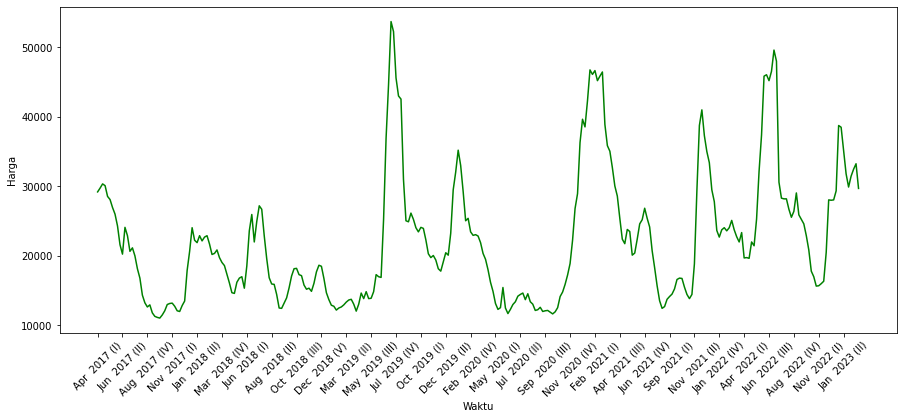

In [40]:
plt.figure(figsize=(15,6))
plt.plot(df_copy['Komoditas (Rp)'], df['Jawa Timur'], color='green')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.xticks(np.arange(0,len(df_copy.index)-1,10))
plt.show()

In [41]:
sd = statistics.pstdev(df_copy['Jawa Timur'].to_numpy())
meanS = statistics.mean(df_copy['Jawa Timur'].to_numpy())
print("Koefisien Variasi = ",sd/meanS*100,"%")

Koefisien Variasi =  41.526564334561655 %


In [42]:
Dt = df_copy['Jawa Timur']
Dmin = Dt.min()
Dmax = Dt.max()
N = Dt.count()
Z1 = 100
Z2 = 100

print(Dmin, Dmax, N)

11050 53700 307


In [43]:
R = Dmax+Z2 - (Dmin-Z1)
print(R)

42850


In [44]:
dif = []
df2 = df_copy

for i in range (N-1):
    dt = df['Jawa Timur'][i]
    dt2 = df['Jawa Timur'][i+1]
    ab = round(abs(dt2-dt),2)
    df2.at[i, '|Dt+1 - Dt|'] = ab

df2.at[N-1, '|Dt+1 - Dt|'] = 0

In [45]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|
0,Apr 2017 (I),40259,29200,550.0
1,Apr 2017 (II),39954,29750,600.0
2,Apr 2017 (III),37914,30350,250.0
3,Apr 2017 (IV),35500,30100,1550.0
4,May 2017 (V),36431,28550,450.0
...,...,...,...,...
302,Jan 2023 (IV),40269,29900,1550.0
303,Feb 2023 (I),40657,31450,1000.0
304,Feb 2023 (II),42054,32450,800.0
305,Feb 2023 (III),43128,33250,3550.0


In [46]:
mean = (sum(df2['|Dt+1 - Dt|']))/(N-1)
print(mean)

1746.7320261437908


In [47]:
K = mean/2
if(K<1):
    K = round(K,1)
else:
    K = math.ceil(K)

print(K)

874


In [48]:
n = math.ceil(R/K)
print(n)

50


In [49]:
himpFuzzy = pd.DataFrame()
ui = []
batasBawah = []
batasAtas = []
Ai = []
ui.append('u1')
Ai.append('A1')
batasBawah.append(Dmin-Z1)
batasAtas.append(batasBawah[0] + K)

for i in range(1, n):
    ui.append('u'+str(i+1))
    Ai.append('A'+str(i+1))
    batasBawah.append(batasAtas[i-1])
    batasAtas.append(batasBawah[i] + K)

himpFuzzy['ui'] = ui
himpFuzzy['Ai'] = Ai
himpFuzzy['batas bawah'] = batasBawah
himpFuzzy['batas atas'] = batasAtas

In [50]:
himpFuzzy['mi'] = (himpFuzzy['batas bawah'] + himpFuzzy['batas atas'])/2

In [51]:
himpFuzzy

,ui,Ai,batas bawah,batas atas,mi
0,u1,A1,10950,11824,11387.0
1,u2,A2,11824,12698,12261.0
2,u3,A3,12698,13572,13135.0
3,u4,A4,13572,14446,14009.0
4,u5,A5,14446,15320,14883.0
5,u6,A6,15320,16194,15757.0
6,u7,A7,16194,17068,16631.0
7,u8,A8,17068,17942,17505.0
8,u9,A9,17942,18816,18379.0
9,u10,A10,18816,19690,19253.0


In [52]:
# FLR dan FLRG
data = df2['Jawa Timur']

hasilFuzzy = []
for i in data:
    copyHimp = himpFuzzy
    cond1 = copyHimp['batas bawah'] <= i 
    cond2 = copyHimp['batas atas'] >= i 
    dfAi = copyHimp.where(cond1 & cond2) 
    dfAi = dfAi[~dfAi['ui'].isna()]
    fuzzyfikasi = dfAi['Ai'].iloc[0]
    hasilFuzzy.append(fuzzyfikasi)

df2['fuzzyfikasi'] = hasilFuzzy

In [53]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi
0,Apr 2017 (I),40259,29200,550.0,A21
1,Apr 2017 (II),39954,29750,600.0,A22
2,Apr 2017 (III),37914,30350,250.0,A23
3,Apr 2017 (IV),35500,30100,1550.0,A22
4,May 2017 (V),36431,28550,450.0,A21
...,...,...,...,...,...
302,Jan 2023 (IV),40269,29900,1550.0,A22
303,Feb 2023 (I),40657,31450,1000.0,A24
304,Feb 2023 (II),42054,32450,800.0,A25
305,Feb 2023 (III),43128,33250,3550.0,A26


In [54]:
nextState = []
for k in range(0, len(df2.index)-1):
    neSt = df2['fuzzyfikasi'].iloc[k+1]
    nextState.append(neSt)

df2['next state'] = pd.Series(nextState)

In [55]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state
0,Apr 2017 (I),40259,29200,550.0,A21,A22
1,Apr 2017 (II),39954,29750,600.0,A22,A23
2,Apr 2017 (III),37914,30350,250.0,A23,A22
3,Apr 2017 (IV),35500,30100,1550.0,A22,A21
4,May 2017 (V),36431,28550,450.0,A21,A20
...,...,...,...,...,...,...
302,Jan 2023 (IV),40269,29900,1550.0,A22,A24
303,Feb 2023 (I),40657,31450,1000.0,A24,A25
304,Feb 2023 (II),42054,32450,800.0,A25,A26
305,Feb 2023 (III),43128,33250,3550.0,A26,A22


In [56]:
# FLRG
dfFLRG = pd.DataFrame()
dfFLRG['Ai'] = himpFuzzy['Ai']
dfFLRG['FLRG'] = ''

# ambil df2 kecuali baris terakhir karena next statenya kosong
df3 = df2[:-1]

for f in range(len(dfFLRG.index)):
    searchAi = 'A'+str(f+1)
    
    new = df3[df3['fuzzyfikasi'].isin([searchAi])]
    group = new['next state']
    group = group.to_numpy()
    
    if len(group) > 0 :
        dfFLRG['FLRG'][f] = group

In [57]:
dfFLRG

,Ai,FLRG
0,A1,"[A1, A1, A1, A1, A2, A2, A2]"
1,A2,"[A3, A3, A2, A3, A2, A3, A2, A2, A3, A3, A2, A..."
2,A3,"[A2, A1, A3, A3, A3, A2, A3, A8, A4, A3, A2, A..."
3,A4,"[A3, A6, A3, A4, A3, A5, A4, A5, A5, A5, A5, A..."
4,A5,"[A5, A7, A2, A6, A6, A4, A4, A4, A8, A3, A5, A..."
5,A6,"[A5, A9, A6, A5, A8, A5, A5, A8, A2, A8, A3, A..."
6,A7,"[A4, A7, A7, A6, A6, A5, A7, A17, A5, A7, A7, ..."
7,A8,"[A12, A6, A9, A8, A6, A9, A7, A10, A10, A7]"
8,A9,"[A7, A8, A15, A9, A8, A9, A7, A8, A7, A6]"
9,A10,"[A9, A7, A9, A11, A9, A13, A22, A13]"


In [58]:
# hasil fuzzyfikasi
dfFLRG['defuzzyfikasi'] = ''

for g in range(len(dfFLRG.index)):
    ai = dfFLRG['Ai'].loc[g]
    flrg = dfFLRG['FLRG'].loc[g]
    hasil = 0

    if (len(flrg) == 0):
        fuzzyfikasi = himpFuzzy[himpFuzzy['Ai'] == ai]['mi']
        hasil = fuzzyfikasi.values[0]
    
    elif (len(flrg) == 1):
        fuzzyfikasi = himpFuzzy[himpFuzzy['Ai'] == flrg[0]]['mi']
        hasil = fuzzyfikasi.values[0]
        
    else:
        lenFlrg = len(flrg)
        for h in range(len(flrg)):
            mi = himpFuzzy[himpFuzzy['Ai'] == flrg[h]]['mi']
            bobot = (1/len(flrg)) * mi.values[0]
            hasil = hasil + bobot
            

    dfFLRG['defuzzyfikasi'][g] = hasil

In [59]:
dfFLRG

,Ai,FLRG,defuzzyfikasi
0,A1,"[A1, A1, A1, A1, A2, A2, A2]",11761.571429
1,A2,"[A3, A3, A2, A3, A2, A3, A2, A2, A3, A3, A2, A...",12698.0
2,A3,"[A2, A1, A3, A3, A3, A2, A3, A8, A4, A3, A2, A...",13214.454545
3,A4,"[A3, A6, A3, A4, A3, A5, A4, A5, A5, A5, A5, A...",14383.571429
4,A5,"[A5, A7, A2, A6, A6, A4, A4, A4, A8, A3, A5, A...",15028.666667
5,A6,"[A5, A9, A6, A5, A8, A5, A5, A8, A2, A8, A3, A...",15640.466667
6,A7,"[A4, A7, A7, A6, A6, A5, A7, A17, A5, A7, A7, ...",16818.285714
7,A8,"[A12, A6, A9, A8, A6, A9, A7, A10, A10, A7]",17854.6
8,A9,"[A7, A8, A15, A9, A8, A9, A7, A8, A7, A6]",17854.6
9,A10,"[A9, A7, A9, A11, A9, A13, A22, A13]",20673.25


In [60]:
df2['yt'] = ''

for y in range (len(dfFLRG.index)):
    ai = dfFLRG['Ai'].loc[y]
    listAi = df2[df2['fuzzyfikasi'] == ai]
    yt = dfFLRG['defuzzyfikasi'][y]
    
    if len(listAi) > 0:
        idx = listAi.index
        for z in idx:
            df2.at[z+1,'yt'] = yt

In [61]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state,yt
0,Apr 2017 (I),40259.0,29200.0,550.0,A21,A22,
1,Apr 2017 (II),39954.0,29750.0,600.0,A22,A23,28575.666667
2,Apr 2017 (III),37914.0,30350.0,250.0,A23,A22,32144.5
3,Apr 2017 (IV),35500.0,30100.0,1550.0,A22,A21,27701.666667
4,May 2017 (V),36431.0,28550.0,450.0,A21,A20,32144.5
...,...,...,...,...,...,...,...
303,Feb 2023 (I),40657.0,31450.0,1000.0,A24,A25,32144.5
304,Feb 2023 (II),42054.0,32450.0,800.0,A25,A26,31052.0
305,Feb 2023 (III),43128.0,33250.0,3550.0,A26,A22,33892.5
306,Feb 2023 (IV),42562.0,29700.0,0.0,A22,NaN,29449.666667


In [62]:
# MAPE
y_actual = df2['Jawa Timur'][1:-1].to_numpy()
y_predict = df2['yt'][1:-1].to_numpy()

# MAE
MAE = mean_absolute_error(y_actual, y_predict)
print("MAE = ",MAE)

# Root MSE squared=False
RMSE = mean_squared_error(y_actual, y_predict, squared=False)
print("RMSE = ",RMSE)

MAPE = mean_absolute_percentage_error(y_actual, y_predict)
print("MAPE = ",MAPE*100)

MAE =  1486.151728119375
RMSE =  2211.065405758412
MAPE =  6.722459063752205


In [63]:
lastIndex = len(df2.index)
dfPredictNext = df2

dfPredictNext.at[lastIndex-1, 'Komoditas (Rp)'] = 'Periode+1'
for n in range (nPred-1):
    # Add fuzzyfikai dr hasil predict
    nilaiYt = dfPredictNext['yt'][lastIndex-1+n]
    
    copyHimp = himpFuzzy
    cond1 = copyHimp['batas bawah'] <= nilaiYt
    cond2 = copyHimp['batas atas'] >= nilaiYt
    dfAi = copyHimp.where(cond1 & cond2) 
    dfAi = dfAi[~dfAi['ui'].isna()]
    fuzzyfikasi = dfAi['Ai'].iloc[0]
    dfPredictNext.at[lastIndex + n-1, 'fuzzyfikasi'] = fuzzyfikasi

    # add predict
    yt = dfFLRG['defuzzyfikasi'][dfFLRG['Ai'] == fuzzyfikasi]
    dfPredictNext.at[lastIndex+n, 'yt'] = yt.values[0]
    
    dfPredictNext.at[lastIndex+n, 'Komoditas (Rp)'] = "Prediksi+"+str(n+2)
    

In [64]:
dfPredictNext

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state,yt
0,Apr 2017 (I),40259.0,29200.0,550.0,A21,A22,
1,Apr 2017 (II),39954.0,29750.0,600.0,A22,A23,28575.666667
2,Apr 2017 (III),37914.0,30350.0,250.0,A23,A22,32144.5
3,Apr 2017 (IV),35500.0,30100.0,1550.0,A22,A21,27701.666667
4,May 2017 (V),36431.0,28550.0,450.0,A21,A20,32144.5
...,...,...,...,...,...,...,...
315,Prediksi+9,NaN,NaN,NaN,A27,NaN,34111.0
316,Prediksi+10,NaN,NaN,NaN,A27,NaN,34111.0
317,Prediksi+11,NaN,NaN,NaN,A27,NaN,34111.0
318,Prediksi+12,NaN,NaN,NaN,A27,NaN,34111.0


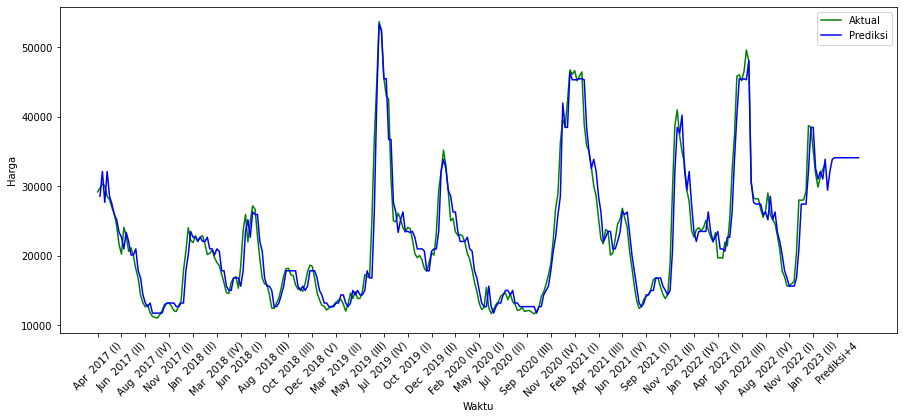

In [65]:
plt.figure(figsize=(15,6))
plt.plot(dfPredictNext['Komoditas (Rp)'][0:306], dfPredictNext['Jawa Timur'][0:306], color='green', label='Aktual')
plt.plot(dfPredictNext['Komoditas (Rp)'][1:len(dfPredictNext.index)], dfPredictNext['yt'][1:len(dfPredictNext.index)], color='blue', label='Prediksi')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.xticks(np.arange(0,len(dfPredictNext.index)-1,10))
plt.legend()
plt.show()

In [66]:
dfMar = pd.read_csv("cabai hijau mar-mei 23.csv", sep=";")
dfMar

,Komoditas (Rp),Semua Provinsi,Jawa Timur
0,Mar 2023 (I),48100,31050
1,Mar 2023 (II),49100,29900
2,Mar 2023 (III),47750,29350
3,Mar 2023 (IV),45750,25700
4,Apr 2023 (I),40550,21550
5,Apr 2023 (II),40550,20650
6,Apr 2023 (III),39500,23350
7,Apr 2023 (IV),39850,23700
8,May 2023 (V),35800,20500
9,May 2023 (I),35900,20300


In [67]:
df_result = pd.DataFrame()
df_result['yt'] = dfPredictNext['yt'][len(dfPredictNext.index)-nPred:].copy()
df_result.reset_index(inplace=True, drop=True)

In [68]:
dfMar['yt'] = df_result
dfMar

,Komoditas (Rp),Semua Provinsi,Jawa Timur,yt
0,Mar 2023 (I),48100,31050,32144.5
1,Mar 2023 (II),49100,29900,33892.5
2,Mar 2023 (III),47750,29350,34111.0
3,Mar 2023 (IV),45750,25700,34111.0
4,Apr 2023 (I),40550,21550,34111.0
5,Apr 2023 (II),40550,20650,34111.0
6,Apr 2023 (III),39500,23350,34111.0
7,Apr 2023 (IV),39850,23700,34111.0
8,May 2023 (V),35800,20500,34111.0
9,May 2023 (I),35900,20300,34111.0


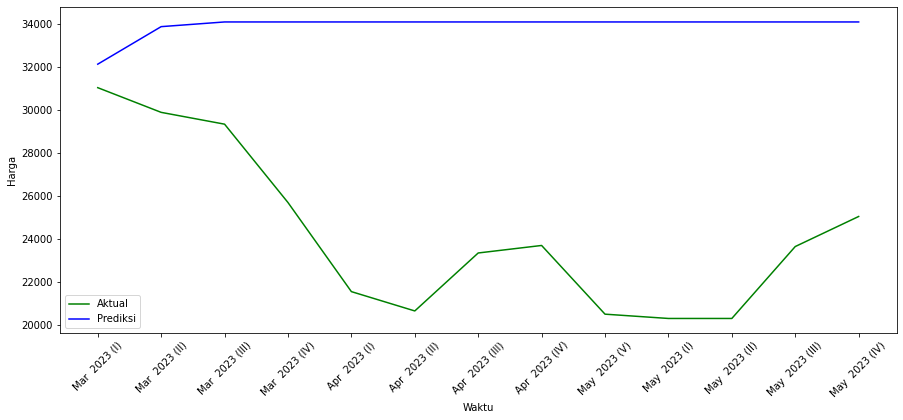

In [69]:
plt.figure(figsize=(15,6))
plt.plot(dfMar['Komoditas (Rp)'], dfMar['Jawa Timur'], color='green', label='Aktual')
plt.plot(dfMar['Komoditas (Rp)'], dfMar['yt'], color='blue', label='Prediksi')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [70]:
# MAPE
y_actual = dfMar['Jawa Timur'].to_numpy()
y_predict = dfMar['yt'].to_numpy()

# MAE
MAE = mean_absolute_error(y_actual, y_predict)
print("MAE = ",MAE)

# Root MSE squared=False
RMSE = mean_squared_error(y_actual, y_predict, squared=False)
print("RMSE = ",RMSE)

MAPE = mean_absolute_percentage_error(y_actual, y_predict)
print("MAPE = ",MAPE*100)

MAE =  9708.307692307691
RMSE =  10495.406751746947
MAPE =  43.24486640180535
